# 📉 Módulo 3.4: Reducción de Dimensionalidad
### Curso: **Machine Learning con Python** (IFCD093PO)
**Duración estimada:** 8 horas

---

## 🎯 Objetivos del Módulo

Bienvenido a una de las técnicas más poderosas y versátiles del Machine Learning. La reducción de dimensionalidad no solo nos ayuda a visualizar datos complejos, sino que también puede mejorar el rendimiento de nuestros modelos y reducir la carga computacional. En este módulo, desmitificaremos cómo funciona y exploraremos sus algoritmos más importantes.

Al finalizar, serás capaz de:

- ✅ Entender la **"Maldición de la Dimensionalidad"** y por qué reducir características es a menudo una buena idea.
- ✅ Aplicar e interpretar el **Análisis de Componentes Principales (PCA)**, la técnica de reducción de dimensionalidad más fundamental.
- ✅ Utilizar **t-SNE** y **UMAP**, dos potentes algoritmos de Manifold Learning, para crear visualizaciones 2D/3D impresionantes de datasets de alta dimensión.
- ✅ Elegir entre PCA (para preservación de varianza) y t-SNE/UMAP (para preservación de estructura local) según el objetivo.
- ✅ Usar las componentes reducidas como entrada para otros modelos de Machine Learning.

**¡Prepárate para transformar datos de cientos de dimensiones en visualizaciones claras y concisas!**

---

## 📚 Tabla de Contenidos

1. [¿Por Qué Reducir la Dimensionalidad?](#1-por-que)
   - [La Maldición de la Dimensionalidad](#1.1-maldicion)
   - [Visualización y Eficiencia](#1.2-visualizacion)
2. [Análisis de Componentes Principales (PCA)](#2-pca)
   - [Intuición: Encontrando las Direcciones de Máxima Varianza](#2.1-intuicion-pca)
   - [Implementación con Scikit-Learn](#2.2-implementacion-pca)
   - [Varianza Explicada y Elección del Número de Componentes](#2.3-varianza-explicada)
   - [Ventajas y Desventajas de PCA](#2.4-ventajas-pca)
3. [Manifold Learning para Visualización](#3-manifold)
   - [t-SNE (t-Distributed Stochastic Neighbor Embedding)](#3.1-tsne)
   - [UMAP (Uniform Manifold Approximation and Projection)](#3.2-umap)
4. [PCA vs. t-SNE vs. UMAP](#4-comparativa)
5. [Ejercicios Prácticos](#5-ejercicios)
6. [Resumen y Próximos Pasos](#6-resumen)

---

## 🤔 1. ¿Por Qué Reducir la Dimensionalidad? <a id='1-por-que'></a>

Trabajar con datasets que tienen muchas características (alta dimensionalidad) presenta varios problemas.

### 1.1 La Maldición de la Dimensionalidad <a id='1.1-maldicion'></a>

Este término se refiere a varios fenómenos que aparecen al analizar datos en espacios de alta dimensión:

- **Datos Dispersos**: A medida que añades dimensiones, el volumen del espacio crece exponencialmente. Para mantener la misma densidad de datos, necesitarías una cantidad de datos que también crece exponencialmente. En la práctica, tus datos se vuelven muy dispersos.
- **Distancias menos significativas**: En dimensiones muy altas, las distancias entre los puntos tienden a igualarse, lo que hace que los algoritmos basados en distancia (como KNN o clustering) sean menos efectivos.
- **Mayor riesgo de Overfitting**: Con más características que muestras, es más fácil para un modelo "memorizar" los datos de entrenamiento en lugar de aprender patrones generales.

### 1.2 Visualización y Eficiencia <a id='1.2-visualizacion'></a>

- **Visualización**: Los humanos no podemos ver más allá de 3 dimensiones. Para explorar un dataset con 50 características, necesitamos una forma de "comprimirlo" en 2D o 3D.
- **Eficiencia**: Menos características significan modelos más rápidos de entrenar y menos memoria requerida.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits, load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
# UMAP no está en scikit-learn, necesita instalarse por separado: pip install umap-learn
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("UMAP no está instalado. Para usarlo, ejecuta: pip install umap-learn")

sns.set_style('whitegrid')

# --- Datasets ---

# 1. Iris: 4 dimensiones, fácil de visualizar reducido
iris = load_iris()
X_iris = iris.data # Sepal length, Sepal width, Petal length, Petal width
y_iris = iris.target # 0: setosa, 1: versicolor, 2: virginica
X_iris_scaled = StandardScaler().fit_transform(X_iris)

# 2. Digits: 64 dimensiones (8x8 píxeles), un buen caso para reducción
digits = load_digits()
X_digits = digits.data # 64 características (píxeles)
y_digits = digits.target # Dígitos del 0 al 9
X_digits_scaled = StandardScaler().fit_transform(X_digits)

print(f"Dataset Iris: {X_iris.shape[0]} muestras, {X_iris.shape[1]} dimensiones")
print(f"Dataset Digits: {X_digits.shape[0]} muestras, {X_digits.shape[1]} dimensiones")

Dataset Iris: 150 muestras, 4 dimensiones
Dataset Digits: 1797 muestras, 64 dimensiones


---

## ✨ 2. Análisis de Componentes Principales (PCA) <a id='2-pca'></a>

PCA es una técnica de **reducción de dimensionalidad lineal**. Su objetivo es transformar los datos a un nuevo sistema de coordenadas donde la mayor parte de la varianza de los datos se concentra en las primeras coordenadas.

### 2.1 Intuición: Encontrando las Direcciones de Máxima Varianza <a id='2.1-intuicion-pca'></a>

Imagina un conjunto de datos en 2D con forma de elipse. PCA encontrará dos nuevos ejes (componentes principales):

- **Componente Principal 1 (PC1)**: La dirección en la que los datos varían más. Es el eje más largo de la elipse.
- **Componente Principal 2 (PC2)**: La siguiente dirección de máxima varianza, que es ortogonal (perpendicular) a PC1.

Para reducir de 2D a 1D, simplemente proyectamos todos los puntos sobre PC1, conservando la mayor cantidad de información (varianza) posible.
![PCA Intuition](imagenes/intuicion-pca01.png)

Imagina que tienes un conjunto de datos con dos variables: la altura y el peso de varias personas. 

En un gráfico 2D, cada persona es un punto con su altura y peso. Estos dos datos están correlacionados, ya que generalmente, a mayor altura, mayor peso.

Aplicación de PCA paso a paso
1. Datos originales (2D):
Cada punto tiene dos coordenadas: altura y peso.

2. Buscar la dirección de máxima variabilidad (PC1):
PCA encuentra la línea (dirección) a lo largo de la cual los puntos están más dispersos, que podría ser una combinación de altura y peso. Esta línea es el primer componente principal (PC1).

3. Buscar la segunda componente (PC2):
Luego, encuentra la dirección perpendicular a PC1 donde hay la segunda mayor variabilidad.

4. Reducir dimensión (de 2D a 1D):
Si decides quedarte solo con PC1, proyectas todos los puntos sobre esta línea. Así reduces dos variables a una, sin perder casi información esencial.

Ejemplo numérico sencillo, supón estos datos:

| Persona | Altura (cm) | Peso (kg) |
|---|---:|---:|
| A | 170 | 65 |
| B | 160 | 60 |
| C | 180 | 70 |

PCA dirá que el primer componente combina altura y peso en una sola variable que captura la mayor parte de la variación (una mezcla ponderada de altura y peso), por ejemplo:

PC1 = 0.7 × Altura + 0.7 × Peso

Proyectar cada persona en PC1 da un valor único representando su posición en ese nuevo eje resumen, simplificando el análisis de datos y facilitando el uso en modelos o visualizaciones.​

Con este ejemplo se entiende cómo PCA transforma datos originales correlacionados en nuevas variables independientes que resumen la información original de forma eficiente.

![PCA Intuition](imagenes/intuicion-pca01.jpg)


--- Aplicando PCA al dataset Digits ---
Dimensiones originales: (1797, 64)
Dimensiones reducidas: (1797, 2)


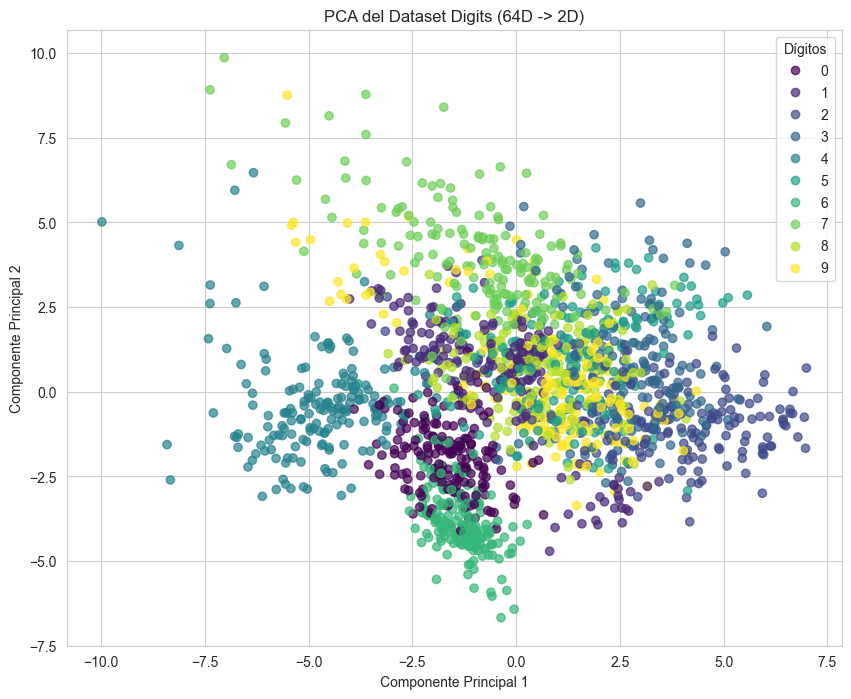

In [2]:
print("--- Aplicando PCA al dataset Digits ---")

# Instanciamos PCA para reducir a 2 componentes
pca = PCA(n_components=2)

# Ajustamos y transformamos los datos
X_digits_pca = pca.fit_transform(X_digits_scaled)

print(f"Dimensiones originales: {X_digits_scaled.shape}")
print(f"Dimensiones reducidas: {X_digits_pca.shape}")

# Visualizamos los resultados
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_digits_pca[:, 0], X_digits_pca[:, 1], c=y_digits, cmap='viridis', alpha=0.7)
plt.title('PCA del Dataset Digits (64D -> 2D)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

# Construir la leyenda de forma robusta usando el desempaquetado de legend_elements
plt.legend(*scatter.legend_elements(), title='Dígitos')
plt.show()

### 2.3 Varianza Explicada y Elección del Número de Componentes <a id='2.3-varianza-explicada'></a>

¿Cómo sabemos si 2 componentes son suficientes? PCA nos dice cuánta de la varianza original de los datos es "explicada" por cada componente.

Podemos graficar la **varianza explicada acumulada** para decidir cuántos componentes retener. Una regla común es retener suficientes componentes para explicar el 95% de la varianza.

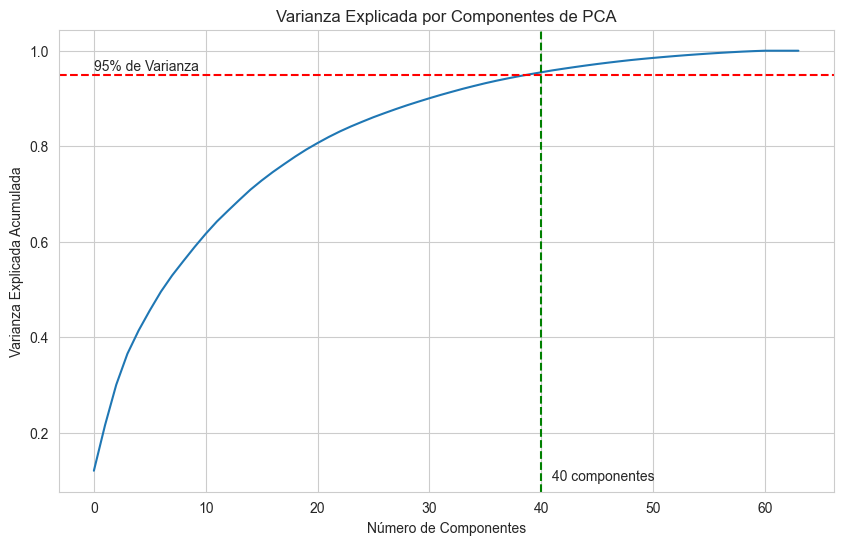

Para retener el 95% de la varianza, necesitamos 40 componentes de los 64 originales.


In [3]:
# Aplicar PCA reteniendo todos los componentes para ver la varianza explicada
pca_full = PCA().fit(X_digits_scaled)

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Varianza Explicada por Componentes de PCA')
plt.grid(True)

# Línea para el 95% de varianza
plt.axhline(y=0.95, color='r', linestyle='--')
plt.text(0, 0.96, '95% de Varianza')

# Encontrar el número de componentes para el 95%
n_components_95 = np.where(np.cumsum(pca_full.explained_variance_ratio_) >= 0.95)[0][0] + 1
plt.axvline(x=n_components_95, color='g', linestyle='--')
plt.text(n_components_95 + 1, 0.1, f'{n_components_95} componentes')

plt.show()

print(f"Para retener el 95% de la varianza, necesitamos {n_components_95} componentes de los 64 originales.")

### 2.4 Ventajas y Desventajas de PCA <a id='2.4-ventajas-pca'></a>

**Ventajas:**

✅ **Rápido y determinista**: Es un cálculo matricial directo, sin iteraciones aleatorias.

✅ **Interpretable**: Los componentes principales nos dicen qué direcciones son más importantes y cuánta varianza capturan.

✅ **Elimina la correlación**: Las componentes resultantes no están correlacionadas entre sí, lo cual es útil para algunos modelos.

**Desventajas:**

❌ **Lineal**: No puede capturar relaciones no lineales complejas en los datos.

❌ **Sensible al escalado**: Es crucial escalar los datos antes de aplicar PCA.

❌ **Menos interpretable que las características originales**: Un componente principal es una combinación lineal de todas las características originales, lo que puede dificultar su interpretación en términos de negocio.

---

## 🗺️ 3. Manifold Learning para Visualización <a id='3-manifold'></a>

PCA es genial, pero ¿y si la estructura de nuestros datos no es lineal? Aquí es donde entra el **Manifold Learning**. La idea es que los datos de alta dimensión en realidad podrían yacer en una "variedad" (manifold) de menor dimensión incrustada en ese espacio.

Imagina una hoja de papel enrollada en 3D. Es un objeto 3D, pero su estructura intrínseca es 2D. Los algoritmos de Manifold Learning intentan "desenrollar" esta hoja para encontrar su verdadera dimensionalidad.

Nos centraremos en dos algoritmos muy populares para la visualización: **t-SNE** y **UMAP**.

### 3.1 t-SNE (t-Distributed Stochastic Neighbor Embedding) <a id='3.1-tsne'></a>

- **Objetivo**: t-SNE se enfoca en preservar la **estructura local** de los datos. Intenta que los puntos que son vecinos cercanos en el espacio de alta dimensión también sean vecinos cercanos en el espacio de baja dimensión.
- **Uso Principal**: Visualización. Es excelente para ver cómo se agrupan los datos.
- **A Considerar**: 
  - Es computacionalmente **costoso** y lento en datasets grandes.
  - Los tamaños de los clústeres y las distancias entre ellos en el gráfico de t-SNE **no son necesariamente significativos**.
  - Es sensible al hiperparámetro `perplexity`.

--- Aplicando t-SNE al dataset Digits ---


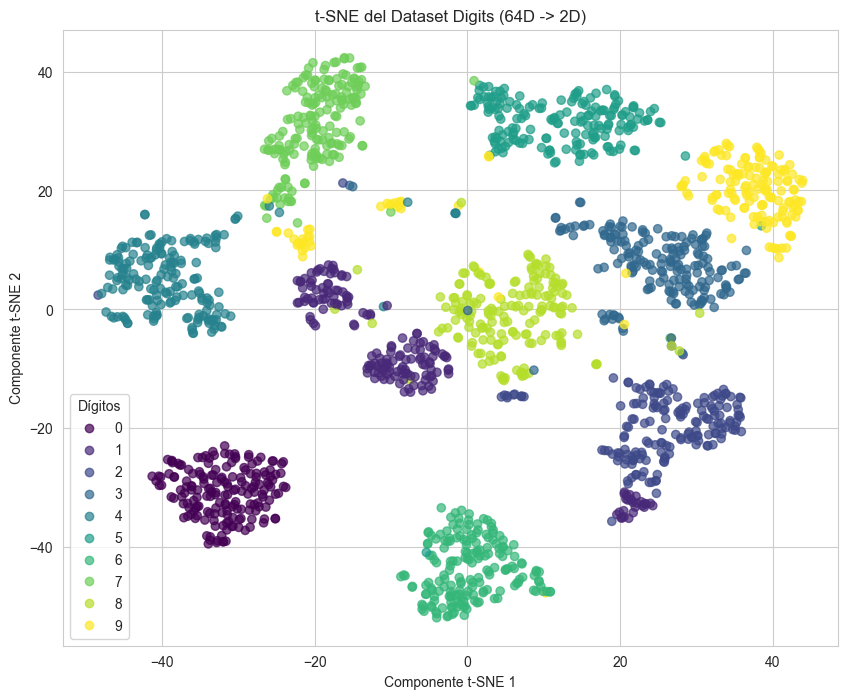

In [7]:
print("--- Aplicando t-SNE al dataset Digits ---")

# t-SNE es costoso, a menudo se aplica después de una primera reducción con PCA
pca_40 = PCA(n_components=40) # Reducimos primero a 40 dimensiones
X_digits_pca_40 = pca_40.fit_transform(X_digits_scaled) # Datos reducidos a 40D

tsne = TSNE(n_components=2, perplexity=30, random_state=42) # Instanciamos t-SNE
# Parametros:
# - n_components: número de dimensiones a las que reducir (2 en este caso)
# - perplexity: un hiperparámetro importante que afecta la calidad de la reducción
# la calidad de la reducción es sensible a este valor a más alto, más global es la vista
X_digits_tsne = tsne.fit_transform(X_digits_pca_50) # Usamos los datos pre-reducidos

# Visualizamos los resultados
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_digits_tsne[:, 0], X_digits_tsne[:, 1], c=y_digits, cmap='viridis', alpha=0.7)
plt.title('t-SNE del Dataset Digits (64D -> 2D)')
plt.xlabel('Componente t-SNE 1')
plt.ylabel('Componente t-SNE 2')
# Construir la leyenda de forma robusta usando el desempaquetado de legend_elements
plt.legend(*scatter.legend_elements(), title='Dígitos')
plt.show()

**Análisis del Resultado:** ¡Impresionante! t-SNE produce clústeres mucho más definidos y separados que PCA. Es evidente cómo cada dígito forma un grupo distinto. Esto lo convierte en una herramienta de visualización superior a PCA.

### 3.2 UMAP (Uniform Manifold Approximation and Projection) <a id='3.2-umap'></a>

- **Objetivo**: Similar a t-SNE, UMAP busca modelar la variedad de los datos, pero a menudo logra un mejor equilibrio entre preservar la estructura local (vecinos cercanos) y la **estructura global** (posiciones relativas de los clústeres).
- **Uso Principal**: Visualización y, a veces, como paso de preprocesamiento.
- **A Considerar**:
  - Es **mucho más rápido** que t-SNE.
  - Generalmente, las distancias globales en el gráfico de UMAP son más significativas que en t-SNE.
  - Se considera el sucesor moderno de t-SNE.

--- Aplicando UMAP al dataset Digits ---


C:\Users\Jaf\AppData\Roaming\Python\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


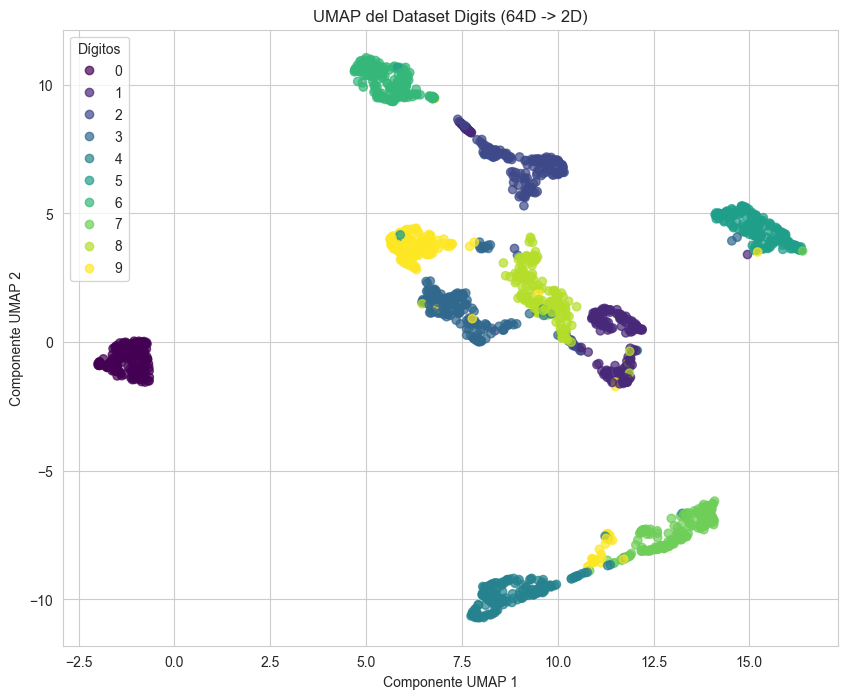

In [10]:
if UMAP_AVAILABLE:
    print("--- Aplicando UMAP al dataset Digits ---")

    # UMAP es rápido, no siempre necesita pre-reducción con PCA
    umap_reducer = umap.UMAP(n_components=2, random_state=42) # Instanciamos UMAP
    X_digits_umap = umap_reducer.fit_transform(X_digits_scaled) # Aplicamos UMAP directamente

    # Visualizamos los resultados
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X_digits_umap[:, 0], X_digits_umap[:, 1], c=y_digits, cmap='viridis', alpha=0.7)
    plt.title('UMAP del Dataset Digits (64D -> 2D)')
    plt.xlabel('Componente UMAP 1')
    plt.ylabel('Componente UMAP 2')
    # Construir la leyenda de forma robusta usando el desempaquetado de legend_elements
    plt.legend(*scatter.legend_elements(), title='Dígitos')
    plt.show()
else:
    print("Saltando UMAP porque la librería no está instalada.")

**Análisis del Resultado:** UMAP también produce una excelente separación de los clústeres, a menudo de forma más rápida y con una mejor preservación de la estructura global. Los resultados suelen ser similares o mejores que los de t-SNE.

---

## 🆚 4. PCA vs. t-SNE vs. UMAP <a id='4-comparativa'></a>

| Característica | PCA | t-SNE | UMAP |
| :--- | :--- | :--- | :--- |
| **Tipo** | Lineal | No Lineal (Manifold) | No Lineal (Manifold) |
| **Objetivo Principal** | Preservar varianza global | Preservar estructura local | Preservar estructura local y global |
| **Velocidad** | Muy Rápido | Lento | Rápido |
| **Uso Principal** | Preprocesamiento, compresión | **Visualización** | **Visualización**, preprocesamiento |
| **Interpretabilidad** | Alta (varianza explicada) | Baja (distancias no significativas) | Media (distancias más significativas) |
| **Determinista** | Sí | No (aleatorio) | No (aleatorio) |

**Regla General:**
- ¿Necesitas **preprocesar** datos para un modelo? Empieza con **PCA**.
- ¿Necesitas **visualizar** datos para entender su estructura de agrupamiento? Usa **UMAP**. Si no está disponible, usa **t-SNE**.

---

## 🏋️ 5. Ejercicios Prácticos <a id='5-ejercicios'></a>

1.  **PCA en Iris**: Aplica PCA al dataset `iris` para reducirlo de 4 a 2 dimensiones. Visualiza el resultado y compáralo con la visualización de t-SNE y UMAP. ¿Cuál crees que separa mejor las 3 especies?
2.  **Clustering sobre Datos Reducidos**: Toma el resultado 2D de PCA, t-SNE y UMAP del dataset `digits`. Aplica K-Means (con k=10) a cada uno de estos tres datasets 2D. ¿En cuál de ellos K-Means obtiene los mejores resultados? ¿Por qué crees que es así?
3.  **Varianza en Iris**: Para el dataset `iris`, ¿cuántos componentes principales necesitas para capturar el 99% de la varianza?

---

## 📝 6. Resumen y Próximos Pasos <a id='6-resumen'></a>

### 🎉 ¡Ahora puedes ver lo invisible y simplificar lo complejo!

#### ✅ Lo que has aprendido:

1. **PCA (Análisis de Componentes Principales)**
   - **Qué es**: Una técnica lineal que encuentra las direcciones de máxima varianza.
   - **Cuándo usarlo**: Para preprocesamiento, compresión y una reducción de dimensionalidad rápida y explicable.

2. **t-SNE y UMAP (Manifold Learning)**
   - **Qué son**: Técnicas no lineales que "desenrollan" los datos para encontrar su estructura intrínseca.
   - **Cuándo usarlos**: Principalmente para la visualización de datos de alta dimensión. UMAP es generalmente preferible a t-SNE por su velocidad y mejor preservación de la estructura global.

3. **La Estrategia Correcta**
   - No son mutuamente excluyentes. A menudo se usa PCA para una reducción inicial antes de aplicar t-SNE.
   - Elige la herramienta según tu objetivo: ¿interpretabilidad y varianza (PCA) o agrupamiento visual (UMAP/t-SNE)?

---

### 🚀 Próximo Módulo: Detección de Anomalías

Hemos cubierto el clustering y la reducción de dimensionalidad. Es hora de abordar la tercera y última gran tarea del aprendizaje no supervisado: la **detección de anomalías**.

En el próximo módulo, aprenderás técnicas para encontrar esos "puntos raros" que no encajan con el resto:

- **Isolation Forest**
- **Local Outlier Factor (LOF)**
- **One-Class SVM**

**Has aprendido a encontrar grupos y a simplificar tus datos. Ahora, ¡vamos a aprender a encontrar las agujas en el pajar!**